In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

In [107]:
df = pd.read_csv("cleaned_dataset_fixed.csv")

In [108]:
df.head()

,DateTime,City,AQI,PM2.5,PM10,CO,NO2,SO2,O3,Temperature,Humidity,Wind_Speed,Pressure,Day,Hour,Time_Category
0,2026-04-01 00:00:00,Bangalore,86,28.60,35.99,327.22,11.27,6.68,64.70,20.7,91,8.6,1012.8,Wednesday,0,Morning
1,2026-04-01 01:00:00,Bangalore,86,28.70,35.90,332.78,10.67,6.01,59.96,20.9,85,8.9,1013.3,Wednesday,1,Morning
2,2026-04-01 02:00:00,Bangalore,86,28.72,35.80,329.01,9.63,5.59,56.63,22.0,76,7.2,1013.6,Wednesday,2,Morning
3,2026-04-01 03:00:00,Bangalore,86,28.71,35.71,320.08,8.61,5.24,53.86,24.9,58,5.8,1013.6,Wednesday,3,Morning
4,2026-04-01 04:00:00,Bangalore,86,28.75,35.66,312.57,7.89,4.68,51.41,28.0,36,6.6,1013.8,Wednesday,4,Morning


In [109]:
df.tail()

,DateTime,City,AQI,PM2.5,PM10,CO,NO2,SO2,O3,Temperature,Humidity,Wind_Speed,Pressure,Day,Hour,Time_Category
3019,2026-04-19 19:00:00,Mumbai,82,26.89,68.36,110.43,0.21,0.68,84.25,28.0,73,1.6,1009.1,Sunday,19,Evening
3020,2026-04-19 20:00:00,Mumbai,79,25.56,65.42,109.84,0.21,0.63,84.40,28.2,71,7.7,1009.4,Sunday,20,Evening
3021,2026-04-19 21:00:00,Mumbai,77,24.49,63.07,109.22,0.20,0.59,84.47,28.0,71,7.4,1009.1,Sunday,21,Night
3022,2026-04-19 22:00:00,Mumbai,76,23.77,61.55,108.90,0.18,0.56,84.61,27.6,70,5.2,1008.5,Sunday,22,Night
3023,2026-04-19 23:00:00,Mumbai,74,23.24,60.67,108.23,0.16,0.51,84.58,27.0,74,2.4,1008.6,Sunday,23,Night


In [110]:
df.shape

(3024, 16)

In [111]:
df.columns

Index(['DateTime', 'City', 'AQI', 'PM2.5', 'PM10', 'CO', 'NO2', 'SO2', 'O3',
       'Temperature', 'Humidity', 'Wind_Speed', 'Pressure', 'Day', 'Hour',
       'Time_Category'],
      dtype='object')

In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3024 entries, 0 to 3023
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   DateTime       3024 non-null   object 
 1   City           3024 non-null   object 
 2   AQI            3024 non-null   int64  
 3   PM2.5          3024 non-null   float64
 4   PM10           3024 non-null   float64
 5   CO             3024 non-null   float64
 6   NO2            3024 non-null   float64
 7   SO2            3024 non-null   float64
 8   O3             3024 non-null   float64
 9   Temperature    3024 non-null   float64
 10  Humidity       3024 non-null   int64  
 11  Wind_Speed     3024 non-null   float64
 12  Pressure       3024 non-null   float64
 13  Day            3024 non-null   object 
 14  Hour           3024 non-null   int64  
 15  Time_Category  3024 non-null   object 
dtypes: float64(9), int64(3), object(4)
memory usage: 378.1+ KB


In [113]:
df['DateTime'] = pd.to_datetime(df['DateTime'])

In [114]:
df.isnull().sum()

DateTime         0
City             0
AQI              0
PM2.5            0
PM10             0
CO               0
NO2              0
SO2              0
O3               0
Temperature      0
Humidity         0
Wind_Speed       0
Pressure         0
Day              0
Hour             0
Time_Category    0
dtype: int64

In [115]:
df.duplicated().sum()

np.int64(0)

In [116]:
df.describe()

,DateTime,AQI,PM2.5,PM10,CO,NO2,SO2,O3,Temperature,Humidity,Wind_Speed,Pressure,Hour
count,3024,3024.000000,3024.000000,3024.000000,3024.000000,3024.000000,3024.000000,3024.000000,3024.000000,3024.000000,3024.000000,3024.000000,3024.000000
mean,2026-04-10 16:30:00,76.816138,24.820718,40.135165,237.027860,4.699421,4.150681,78.868816,29.725132,52.614418,8.720966,1009.058433,11.500000
min,2026-04-01 00:00:00,10.000000,2.430000,7.120000,103.140000,0.040000,0.190000,13.340000,16.000000,9.000000,0.000000,1002.000000,0.000000
25%,2026-04-05 11:45:00,54.000000,13.655000,26.225000,169.610000,1.160000,1.870000,53.715000,26.900000,32.000000,5.600000,1007.400000,5.750000
50%,2026-04-10 23:30:00,77.000000,24.670000,36.895000,219.755000,3.345000,3.415000,75.790000,29.200000,52.000000,8.450000,1009.000000,11.500000
75%,2026-04-15 11:15:00,95.000000,32.890000,51.075000,294.082500,7.500000,5.550000,99.360000,32.825000,72.000000,11.600000,1010.800000,17.250000
max,2026-04-19 23:00:00,185.000000,121.690000,142.820000,733.410000,25.540000,24.320000,192.350000,42.000000,100.000000,21.400000,1015.500000,23.000000
std,NaN,28.653679,12.650929,19.532249,96.348299,4.415596,3.267097,32.427261,4.351618,23.667649,4.057995,2.421972,6.923331


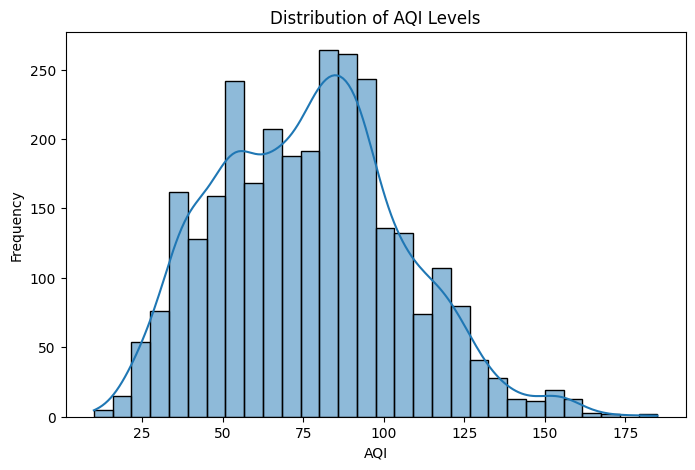

In [117]:

plt.figure(figsize=(8,5))
sns.histplot(df['AQI'], bins=30, kde=True)
plt.title("Distribution of AQI Levels")
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.show()

The AQI distribution is concentrated mostly in the moderate range, indicating generally acceptable air quality conditions.
The slight right skew suggests occasional higher pollution events, but extreme values are relatively infrequent.


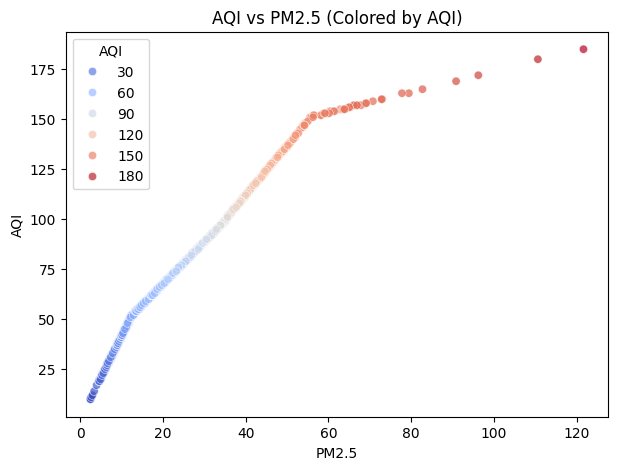

In [118]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    x=df['PM2.5'], 
    y=df['AQI'], 
    hue=df['AQI'], 
    palette='coolwarm',
    alpha=0.7
)
plt.title("AQI vs PM2.5 (Colored by AQI)")
plt.show()


AQI increases sharply with PM2.5 concentration, indicating that fine particulate matter is the dominant factor influencing air quality


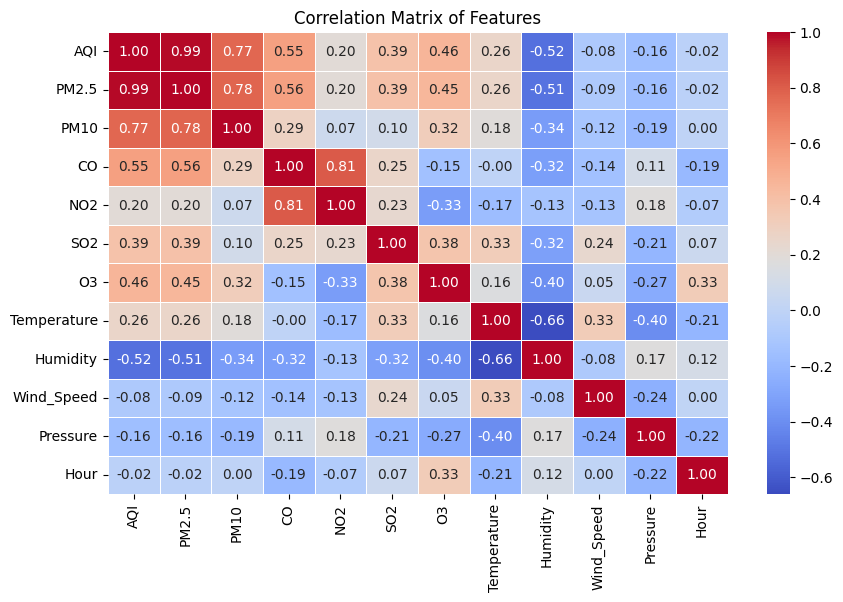

In [119]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Features")
plt.show()

The heatmap shows very strong relationships between AQI and key pollutants, especially PM2.5 and PM10.
These relationships will be analyzed in detail in the report to better understand the factors affecting air quality

C:\Users\Varshith\AppData\Local\Temp\ipykernel_6448\1542553127.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=df['City'], y=df['AQI'], palette='coolwarm')


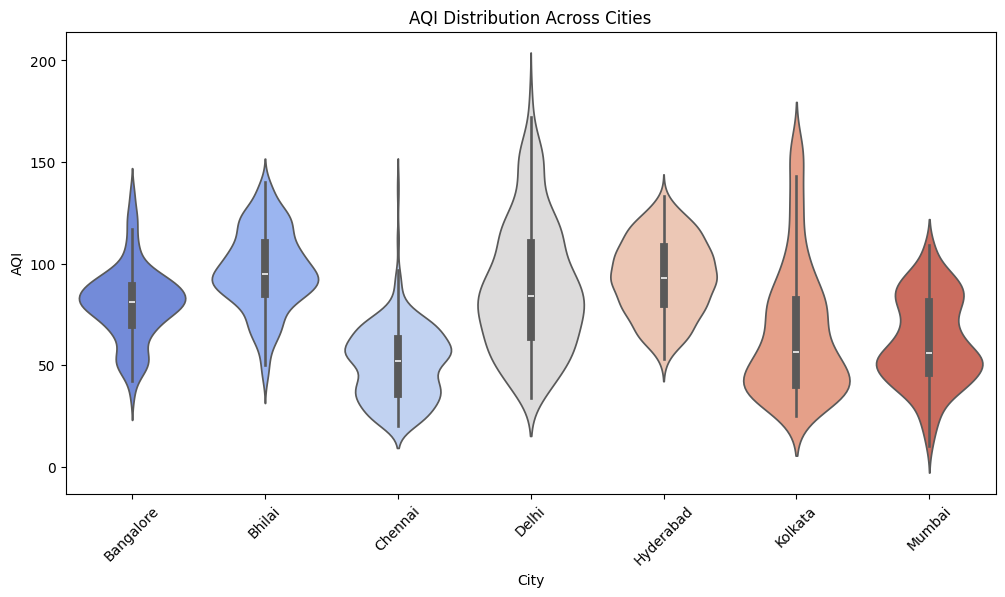

In [120]:
plt.figure(figsize=(12,6))

sns.violinplot(x=df['City'], y=df['AQI'], palette='coolwarm')

plt.title("AQI Distribution Across Cities")
plt.xlabel("City")
plt.ylabel("AQI")
plt.xticks(rotation=45)
plt.show()

The violin plot reveals that AQI levels vary significantly across cities, with some cities experiencing higher variability and frequent pollution spikes

C:\Users\Varshith\AppData\Local\Temp\ipykernel_6448\3341633663.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr.values, y=corr.index, palette='viridis')


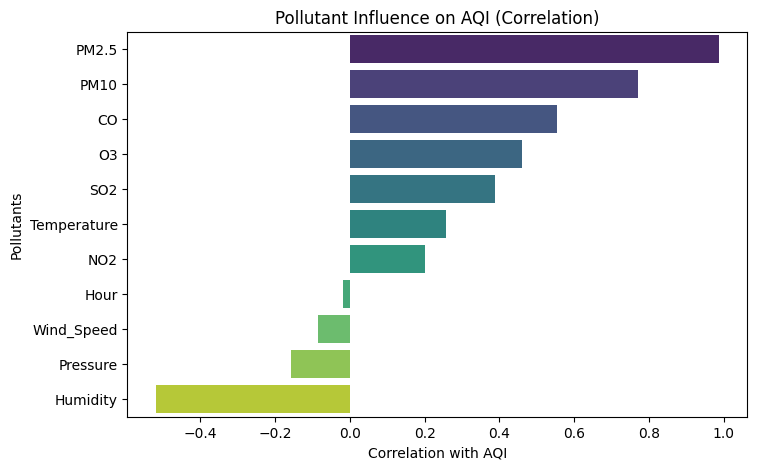

In [121]:
corr = df.corr(numeric_only=True)['AQI'].drop('AQI').sort_values(ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(x=corr.values, y=corr.index, palette='viridis')

plt.title("Pollutant Influence on AQI (Correlation)")
plt.xlabel("Correlation with AQI")
plt.ylabel("Pollutants")
plt.show()

The strong correlation between particulate matter and AQI highlights the need for targeted emission control strategies, while the negative correlation of humidity suggests natural mitigation effects in certain conditions


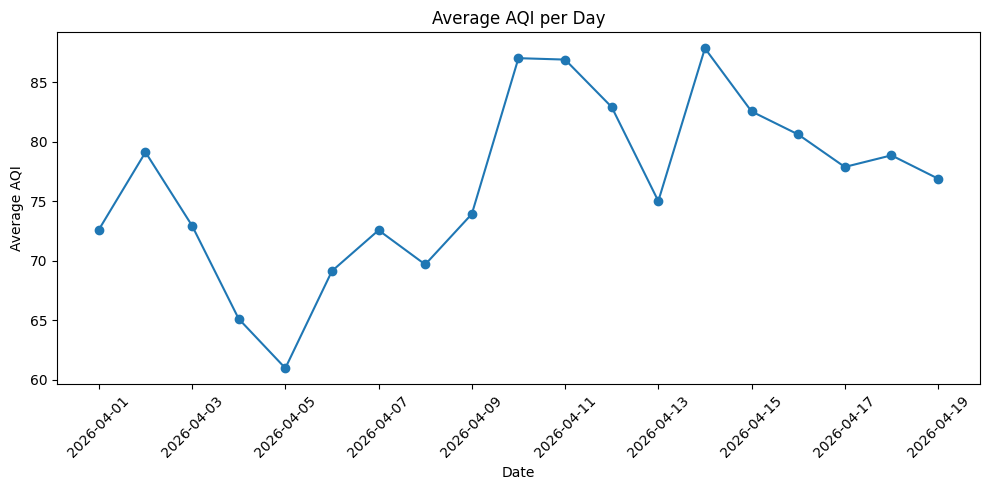

In [122]:
df['DateTime'] = pd.to_datetime(df['DateTime'])
df['Date'] = df['DateTime'].dt.date
daily_avg = df.groupby('Date')['AQI'].mean()
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(daily_avg, marker='o')
plt.title("Average AQI per Day")
plt.xlabel("Date")
plt.ylabel("Average AQI")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

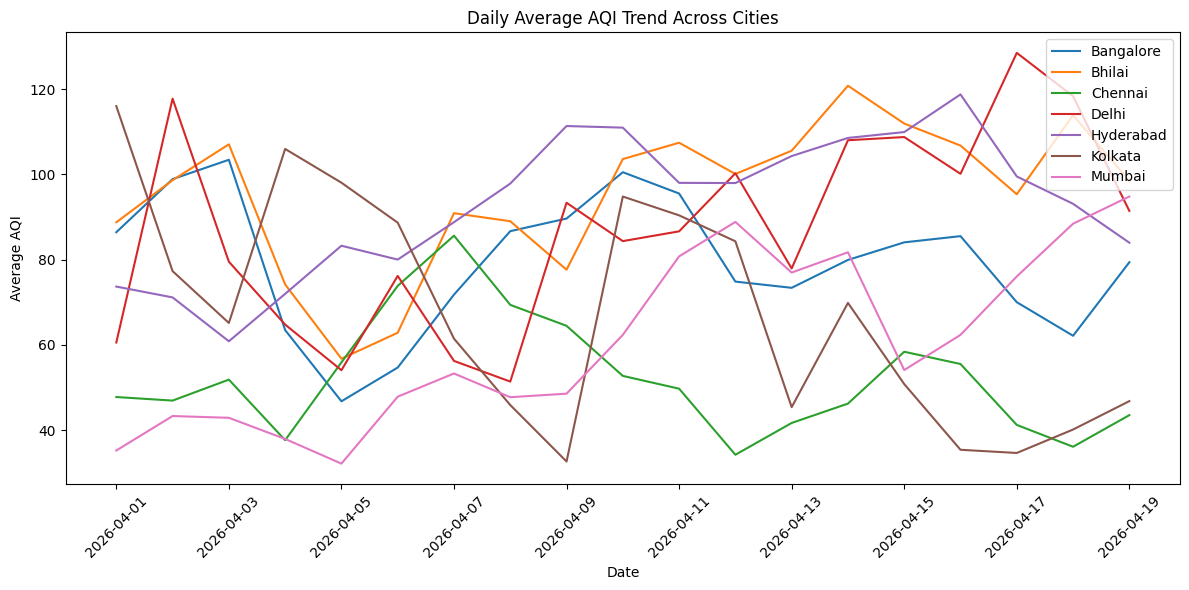

In [123]:
df['DateTime'] = pd.to_datetime(df['DateTime'])
df['Date'] = df['DateTime'].dt.date
daily_city = df.groupby(['City', 'Date'])['AQI'].mean().reset_index()

plt.figure(figsize=(12,6))
for city in daily_city['City'].unique():
    city_data = daily_city[daily_city['City'] == city]
    plt.plot(city_data['Date'], city_data['AQI'], label=city)

plt.title("Daily Average AQI Trend Across Cities")
plt.xlabel("Date")
plt.ylabel("Average AQI")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

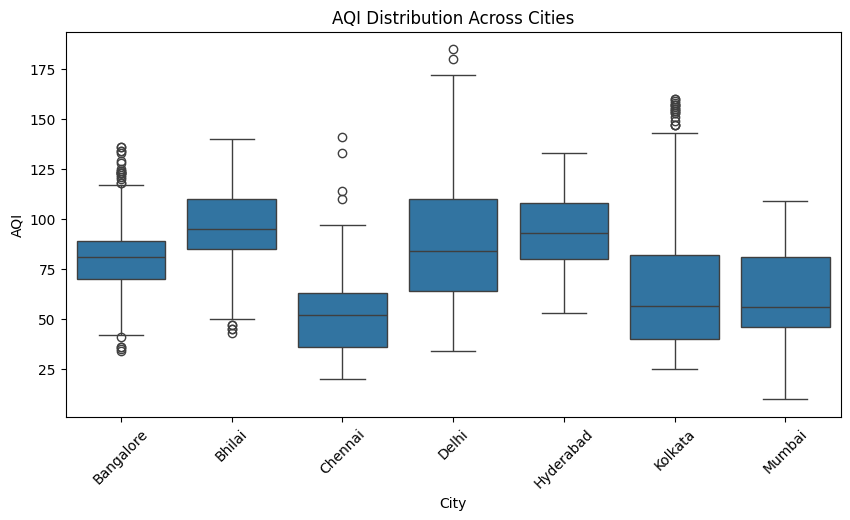

In [124]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df['City'], y=df['AQI'])
plt.xticks(rotation=45)
plt.title("AQI Distribution Across Cities")
plt.show()

----------------------------------------------------MODEL------------------------------------

In [134]:
df[["PM2.5", "PM10", "Temperature", "Humidity"]].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3024 entries, 0 to 3023
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PM2.5        3024 non-null   float64
 1   PM10         3024 non-null   float64
 2   Temperature  3024 non-null   float64
 3   Humidity     3024 non-null   int64  
dtypes: float64(3), int64(1)
memory usage: 94.6 KB


In [135]:
X = df[["PM2.5", "PM10", "Temperature", "Humidity"]]
y = df["AQI"]

print(X.shape, y.shape)

(3024, 4) (3024,)


In [136]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(len(X_train), len(X_test))

2419 605


In [137]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained")

Model trained


In [138]:
y_pred = model.predict(X_test)

y_pred[:5]

array([101.22730463,  79.61497935,  87.05825774, 111.55700003,
        77.75793169])

In [139]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2 Score:", r2)

MSE: 25.96571092359367
R2 Score: 0.9671520074776223


In [141]:
comparison = pd.DataFrame({
    "Actual AQI": y_test.values,
    "Predicted AQI": y_pred
})

comparison.head(10)

,Actual AQI,Predicted AQI
0,101,101.227305
1,80,79.614979
2,87,87.058258
3,111,111.557000
4,80,77.757932
5,71,68.091224
6,129,125.998787
7,160,183.663737
8,48,47.831000
9,66,65.362218


In [142]:
comparison["Error"] = comparison["Actual AQI"] - comparison["Predicted AQI"]

comparison.head(10)

,Actual AQI,Predicted AQI,Error
0,101,101.227305,-0.227305
1,80,79.614979,0.385021
2,87,87.058258,-0.058258
3,111,111.557000,-0.557000
4,80,77.757932,2.242068
5,71,68.091224,2.908776
6,129,125.998787,3.001213
7,160,183.663737,-23.663737
8,48,47.831000,0.169000
9,66,65.362218,0.637782


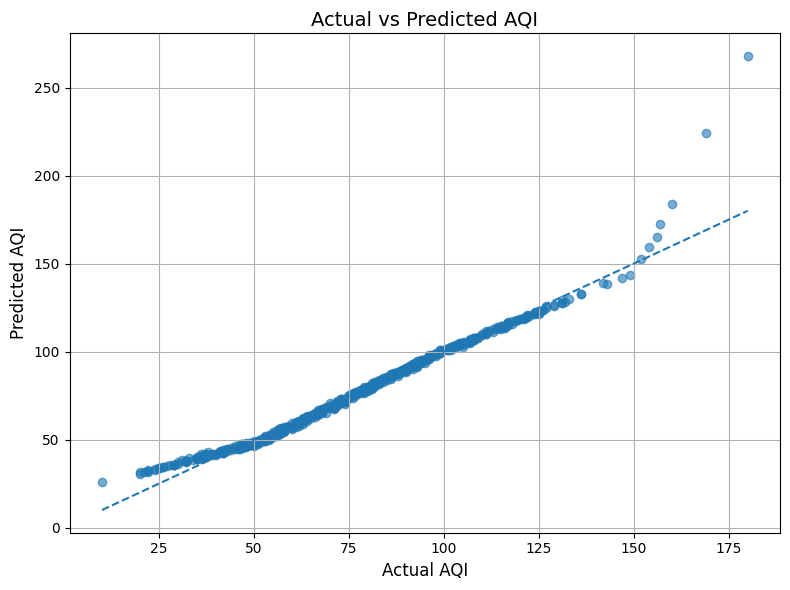

In [144]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.6)

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')

plt.xlabel("Actual AQI", fontsize=12)
plt.ylabel("Predicted AQI", fontsize=12)
plt.title("Actual vs Predicted AQI", fontsize=14)

plt.grid(True)
plt.tight_layout()
plt.show()